In [1]:
## Tools 
## Install Arxiv, Wikipedia, and other dependencies
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

/tmp/ipykernel_941723/3915916479.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
import arxiv as arxiv_lib
arxiv_lib.Client.query_url_format = "https://export.arxiv.org/api/query?{}"

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Search for academic papers on Arxiv.org")
print(arxiv.name, arxiv.description)


arxiv Search for academic papers on Arxiv.org


In [3]:
arxiv.invoke("Sorting a dictionary")

"Published: 2015-08-17\nTitle: Observation of the rare $B^0_s\\toμ^+μ^-$ decay from the combined analysis of CMS and LHCb data\nAuthors: The CMS, LHCb Collaborations, :, V. Khachatryan, A. M. Sirunyan, A. Tumasyan, W. Adam, T. Bergauer, M. Dragicevic, J. Erö, M. Friedl, R. Frühwirth, V. M. Ghete, C. Hartl, N. Hörmann, J. Hrubec, M. Jeitler, W. Kiesenhofer, V. Knünz, M. Krammer, I. Krätschmer, D. Liko, I. Mikulec, D. Rabady, B. Rahbaran, H. Rohringer, R. Schöfbeck, J. Strauss, W. Treberer-Treberspurg, W. Waltenberger, C. -E. Wulz, V. Mossolov, N. Shumeiko, J. Suarez Gonzalez, S. Alderweireldt, S. Bansal, T. Cornelis, E. A. De Wolf, X. Janssen, A. Knutsson, J. Lauwers, S. Luyckx, S. Ochesanu, R. Rougny, M. Van De Klundert, H. Van Haevermaet, P. Van Mechelen, N. Van Remortel, A. Van Spilbeeck, F. Blekman, S. Blyweert, J. D'Hondt, N. Daci, N. Heracleous, J. Keaveney, S. Lowette, M. Maes, A. Olbrechts, Q. Python, D. Strom, S. Tavernier, W. Van Doninck, P. Van Mulders, G. P. Van Onsem, I. Vi

In [4]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=1000)    

wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia, description="Search for information on Wikipedia") 
wiki.name

'wikipedia'

In [5]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["NVIDIA_API_KEY"]=os.getenv("NVIDIA_API_KEY")

print("TAVILY_API_KEY:", os.environ.get("TAVILY_API_KEY"))

TAVILY_API_KEY: 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


In [6]:
# Change TavilySearchResults to TavilySearch
from langchain_tavily import TavilySearch
from dotenv import load_dotenv

load_dotenv()
# Initialize the tool
search_tool = TavilySearch(max_results=3)

# Invoke search
results = search_tool.invoke("What is the oldest human relic from Bengal?")
print(results)


{'query': 'What is the oldest human relic from Bengal?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://orato.world/2024/05/20/in-the-sundarbans-of-west-bengal-museum-owner-scours-the-sea-for-archeological-treasure', 'title': 'In Sundarban mangroves man finds archeological relics', 'content': 'Biswajit Sahu, 55, is the youngest of six siblings and a fisherman by trade. Sahu, from Patharpratima in the Sundarban mangroves in West Bengal, Indian, dropped out of school at a young age. He loves history and after visiting the Indian Museum in 1987 as teenager, discovered his love for archaeology. Later, he heard about the historical importance of an antiquated sculpture discovered in China while listening to the radio. This compelled him to start hunting for artifacts in the river and sea [...] Facebook\n\nFacebook\n\nfb-share-icon\n\nTwitter\n\nVisit Us\n\nFollow Me\n\nPost on X\n\nLinkedIn\n\nLinkedIn\n\nShare\n\n\n\nBiswajit Sahu runs a private mus

In [ ]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

load_dotenv()

# Sanitize API keys by removing invisible characters
logical_key = os.environ.get("TAVILY_API_KEY", "")
cleaned_key = logical_key.replace("\u200b", "").strip()
os.environ["TAVILY_API_KEY"] = cleaned_key

logical_key_nvidia = os.environ.get("NVIDIA_API_KEY", "")
cleaned_key_nvidia = logical_key_nvidia.replace("\u200b", "").strip()
os.environ["NVIDIA_API_KEY"] = cleaned_key_nvidia

search_tool = TavilySearch(max_results=3)

@tool
def academic_search(query: str):
    """Use for academic research, scholarly papers, arXiv papers, technical literature, and research questions. Prefer this tool whenever the user asks for research, citations, studies, or academic findings."""
    return arxiv.invoke(query)

@tool
def web_search(query: str):
    """Use for current web information, news, general facts, and up-to-date events. Do not use for academic papers or research literature."""
    return search_tool.invoke(query)



# Quick sanity checkprint(results)
results = academic_search.invoke("quantum computing research")

{'query': 'What is the oldest human relic from Bengal?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://orato.world/2024/05/20/in-the-sundarbans-of-west-bengal-museum-owner-scours-the-sea-for-archeological-treasure', 'title': 'In Sundarban mangroves man finds archeological relics', 'content': 'Biswajit Sahu, 55, is the youngest of six siblings and a fisherman by trade. Sahu, from Patharpratima in the Sundarban mangroves in West Bengal, Indian, dropped out of school at a young age. He loves history and after visiting the Indian Museum in 1987 as teenager, discovered his love for archaeology. Later, he heard about the historical importance of an antiquated sculpture discovered in China while listening to the radio. This compelled him to start hunting for artifacts in the river and sea [...] Facebook\n\nFacebook\n\nfb-share-icon\n\nTwitter\n\nVisit Us\n\nFollow Me\n\nPost on X\n\nLinkedIn\n\nLinkedIn\n\nShare\n\n\n\nBiswajit Sahu runs a private mus

In [ ]:
## Combine all the tools into a single list 

from langchain_nvidia_ai_endpoints import ChatNVIDIA

tools = [academic_search, web_search, wiki]
llm = ChatNVIDIA(model="meta/llama-3.1-8b-instruct", api_key=cleaned_key_nvidia)
llm.invoke("What is the meaning of Life?")
llm_with_tools = llm.bind_tools(tools=tools)
# Prefer academic_search for research and paper queries.


In [9]:
type(llm_with_tools)

langchain_core.language_models.chat_models._ChatModelBinding

In [10]:
llm_with_tools.invoke("What is the latest research on quantam computing?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call-f9d0fea8-81d6-49fb-9520-c5ae22c2fdfb', 'type': 'function', 'function': {'name': 'web_search', 'arguments': '{"query":"latest research on quantum computing"}'}}]}, response_metadata={'tool_calls': [{'id': 'call-f9d0fea8-81d6-49fb-9520-c5ae22c2fdfb', 'type': 'function', 'function': {'name': 'web_search', 'arguments': '{"query":"latest research on quantum computing"}'}}], 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 433, 'completion_tokens': 22, 'total_tokens': 455, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a01331-4447-7412-ade4-04e08fdf0157-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'latest research on quantum computing'}, 'id': 'call-f9d0fea8-81d6-49fb-9520-c5ae22c2fdfb', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 433,

In [11]:
llm_with_tools.invoke("What is machine learning?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call-beaa6909-d76b-44ad-9230-59a36528989d', 'type': 'function', 'function': {'name': 'wikipedia', 'arguments': '{"query":"machine learning"}'}}]}, response_metadata={'tool_calls': [{'id': 'call-beaa6909-d76b-44ad-9230-59a36528989d', 'type': 'function', 'function': {'name': 'wikipedia', 'arguments': '{"query":"machine learning"}'}}], 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 428, 'completion_tokens': 19, 'total_tokens': 447, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'tool_calls', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--01a01331-4629-7500-b5ab-ede5e6de6066-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'machine learning'}, 'id': 'call-beaa6909-d76b-44ad-9230-59a36528989d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 428, 'output_tokens': 19, 'total_tokens': 447}, role='assistant')

## Workflow

In [12]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage # AnyMessage is a base class for all message types in LangChain, allowing for polymorphism and flexibility in handling different message formats.

from typing import Annotated # Annotated is used to add metadata to types, which can be useful for validation, serialization, and other purposes.
from langgraph.graph.message import add_messages # add_messages is a function that allows you to add message types to a graph, enabling the graph to handle and process different kinds of messages.

In [13]:
class State(TypedDict):
    """State schema for the chatbot."""
    messages: Annotated[list[AnyMessage], add_messages()]  # List of messages in the conversation

In [14]:
### Entire Chatbot with Langgraph
from IPython.display import display, Image, HTML
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode # ToolNode is a prebuilt node in Langgraph that allows you to integrate external tools into your graph, enabling the graph to perform specific actions or retrieve information from those tools.
from langgraph.prebuilt import tools_condition # tools_condition is a prebuilt condition in Langgraph that allows you to define conditions based on the output of tools, enabling the graph to make decisions or take actions based on the results from those tools.

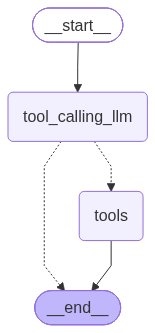

In [15]:
### Node definition
def tool_calling_llm(state: State):
    # Implement the logic for calling the LLM tool here
    return{"messages":llm_with_tools.invoke(state["messages"])}

# Build Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# If the tool condition is met, proceed to the tools node--> tools_condition routes to the tools node
# If the latest message from aasitant is not a tool call --> tools_condition routes to the end node
tools_condition)
builder.add_edge("tools", END)
graph = builder.compile()
# View 

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({"messages": HumanMessage(content="1706.03762")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (call-de4f5088-04b3-45f1-939c-b00914498c2e)
 Call ID: call-de4f5088-04b3-45f1-939c-b00914498c2e
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely

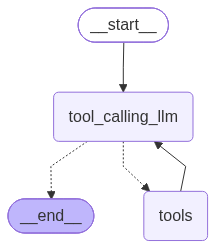

In [17]:
### Node definition
def tool_calling_llm(state: State):
    # Implement the logic for calling the LLM tool here
    return{"messages":llm_with_tools.invoke(state["messages"])}

# Build Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", 
# If the tool condition is met, proceed to the tools node--> tools_condition routes to the tools node
# If the latest message from aasitant is not a tool call --> tools_condition routes to the end node
tools_condition)
builder.add_edge("tools", "tool_calling_llm")
graph = builder.compile()
# View 

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
from langchain_core.messages import HumanMessage

messages=graph.invoke({"messages": HumanMessage(content="Hi my name is Kanad, please tell me about the latest research on quantum computing")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Kanad, please tell me about the latest research on quantum computing
================================== Ai Message ==================================
Tool Calls:
  web_search (call-fa126498-b3c9-42b3-98b7-1e2f5cc08f45)
 Call ID: call-fa126498-b3c9-42b3-98b7-1e2f5cc08f45
  Args:
    query: latest research on quantum computing
================================= Tool Message =================================
Name: web_search

{"query": "latest research on quantum computing", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.nsf.gov/science-matters/quantum-computing-expanding-whats-possible", "title": "Quantum computing: Expanding what's possible | NSF - U.S. National Science Foundation", "content": "NSF researchers are chipping away at long-standing challenges in quantum computing, like error correction and scalability. In 2025, research groups at two NS